# Tratamento dos textos pra extração de features

In [2]:
import math
import re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from spellchecker import SpellChecker
from nltk.corpus import stopwords
from sklearn.preprocessing import StandardScaler

# Downloads do NLTK (executa apenas uma vez)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True) 

# ==========================================
# 1. CLASSE EXTRATORA DE FEATURES (OTIMIZADA)
# ==========================================
class TextFeatureExtractor:
    def __init__(self, max_vocab=1500):
        self.max_vocab = max_vocab
        self.spell = SpellChecker()
        self.vocab = None
        self.vocab_set = None
        self.idf = None
        
        # Tracking GLTR
        self.unigram_counts = Counter()
        self.bigram_counts = Counter()
        self.bigram_ranks = {}
        
        self.stopwords = set(stopwords.words("english"))
        self.LLM_BUZZWORDS = {
            'furthermore','moreover','delve','tapestry',
            'testament','pivotal','underscore','multifaceted',
            'crucial','consequently'
        }
        self.FUNCTION_WORDS = {
            'the','of','to','and','a','in','that','is','it','for','on','with',
            'as','at','this','by','from','or','an','be','are','was','were'
        }

    def _get_gltr_metrics(self, words):
        """Calcula a distribuição de GLTR (Top 10, Top 100, etc.) em tempo O(1)"""
        if len(words) < 2 or not self.bigram_ranks:
            return 0, 0, 0, 0
            
        bigrams = list(zip(words, words[1:]))
        top_10 = top_100 = top_1000 = rest = 0
        
        for w1, w2 in bigrams:
            # Procura instantânea do ranking!
            rank = self.bigram_ranks.get((w1, w2), None)
            
            if rank is None:
                rest += 1
            elif rank <= 10:
                top_10 += 1
            elif rank <= 100:
                top_100 += 1
            elif rank <= 1000:
                top_1000 += 1
            else:
                rest += 1
                
        total = len(bigrams)
        return top_10/total, top_100/total, top_1000/total, rest/total

    def _get_metrics(self, text):
        sentences = sent_tokenize(text)
        raw_tokens = word_tokenize(text)
        words = [w.lower() for w in raw_tokens if w.isalpha()]
    
        if not words:
            return [0] * 24 # 16 originais + 8 novas
    
        # ---------- BASIC FEATURES ----------
        s_lengths = [len(word_tokenize(s)) for s in sentences]
        burst = np.std(s_lengths) if len(sentences) > 1 else 0
        typos = len(self.spell.unknown(words)) / len(words)
        counts = Counter(words)
        total = len(words)
        ent = sum(-(c/total)*math.log2(c/total) for c in counts.values())
        ttr_val = len(set(words))/len(words)
        awl = np.mean([len(w) for w in words])
        asl = len(words)/len(sentences) if sentences else 0
        buzz = sum(w in self.LLM_BUZZWORDS for w in words)/len(words)
        
        tags = nltk.pos_tag(raw_tokens)
        adj = sum(tag.startswith('JJ') for _,tag in tags)/len(raw_tokens) if raw_tokens else 0
        punct = (text.count('!') + text.count('?') + text.count('...')) / len(text) if text else 0
    
        # ---------- NGRAM FEATURES ----------
        bigrams = list(zip(words, words[1:]))
        unique_bigrams = len(set(bigrams))
        bigram_ratio = unique_bigrams / len(bigrams) if bigrams else 0
        text_clean = text.replace(" ", "_")
        char_trigrams = [text_clean[i:i+3] for i in range(len(text_clean)-2)]
        char_trigram_density = len(set(char_trigrams)) / len(char_trigrams) if char_trigrams else 0
    
        # ---------- PERPLEXITY ----------
        unigram_counts = Counter(words)
        bigram_counts = Counter(bigrams)
        log_prob_sum = 0
        N = len(bigrams)
        for w1, w2 in bigrams:
            p = (bigram_counts[(w1,w2)] + 1) / (unigram_counts[w1] + len(unigram_counts))
            log_prob_sum += math.log2(p)
        perplexity = 2 ** (-log_prob_sum / N) if N > 0 else 0
    
        # ---------- POS FEATURES ----------
        pos_tags = [tag for _,tag in tags]
        pos_counts = Counter(pos_tags)
        pos_total = len(pos_tags)
        pos_entropy = sum(-(c/pos_total)*math.log2(c/pos_total) for c in pos_counts.values())
    
        # ---------- RHYTHM, STOPWORD E RARE WORD ----------
        rhythm_var = np.var(s_lengths) if len(s_lengths) > 1 else 0
        stop_ratio = sum(w in self.stopwords for w in words)/len(words)
        rare_words = [w for w,c in counts.items() if c == 1]
        rare_ratio = len(rare_words)/len(words)
        
        # ==========================================
        # ---------- AS 8 NOVAS FEATURES -----------
        # ==========================================
        
        # 1. Function Word Ratio & Entropy
        fw = [w for w in words if w in self.FUNCTION_WORDS]
        fw_ratio = len(fw) / len(words)
        if fw:
            fw_counts = Counter(fw)
            fw_total = len(fw)
            fw_entropy = sum(-(c/fw_total)*math.log2(c/fw_total) for c in fw_counts.values())
        else:
            fw_entropy = 0
            
        # 2. Repetition Distance
        last_seen = {}
        distances = []
        for i, w in enumerate(words):
            if w in last_seen:
                distances.append(i - last_seen[w])
            last_seen[w] = i
        rep_distance = np.mean(distances) if distances else 0
        
        # 3. Sentence Length Entropy
        if s_lengths:
            sl_counts = Counter(s_lengths)
            sl_total = len(s_lengths)
            sl_entropy = sum(-(c/sl_total)*math.log2(c/sl_total) for c in sl_counts.values())
        else:
            sl_entropy = 0
            
        # 4. GLTR Approach
        gltr_top10, gltr_top100, gltr_top1000, gltr_rest = self._get_gltr_metrics(words)
    
        return [
            burst, typos, ent, ttr_val, awl, asl, buzz, adj, punct,
            bigram_ratio, char_trigram_density, perplexity, pos_entropy,
            rhythm_var, stop_ratio, rare_ratio,
            fw_ratio, fw_entropy, rep_distance, sl_entropy,
            gltr_top10, gltr_top100, gltr_top1000, gltr_rest
        ]

    def fit_tfidf(self, corpus):
        tokenized = [re.findall(r'\b[a-zA-Z]+\b', doc.lower()) for doc in corpus]
        doc_freq = Counter()
        
        for doc in tokenized:
            for word in set(doc):
                doc_freq[word] += 1
            
            # Tracking GLTR
            self.unigram_counts.update(doc)
            self.bigram_counts.update(zip(doc, doc[1:]))
            
        self.vocab = [w for w, _ in doc_freq.most_common(self.max_vocab)]
        self.vocab_set = set(self.vocab)
        N = len(corpus)
        self.idf = {w: math.log((1+N)/(1+doc_freq[w])) + 1 for w in self.vocab}
        
        # --- PRÉ-COMPUTAÇÃO GLTR (A Magia da Velocidade) ---
        following_dict = defaultdict(list)
        for (w1, w2), count in self.bigram_counts.items():
            following_dict[w1].append((w2, count))
            
        self.bigram_ranks = {}
        for w1, following in following_dict.items():
            following.sort(key=lambda x: x[1], reverse=True) 
            for rank, (w2, count) in enumerate(following):
                self.bigram_ranks[(w1, w2)] = rank + 1

    def transform_tfidf(self, corpus):
        matrix = []
        for doc in corpus:
            words = re.findall(r'\b[a-zA-Z]+\b', doc.lower())
            tf = Counter(words)
            length = len(words) if words else 1
            row = [(tf.get(w, 0)/length) * self.idf[w] for w in self.vocab]
            matrix.append(row)
        return np.array(matrix)

    def fit_transform(self, corpus):
        corpus = [str(t) for t in corpus]
        self.fit_tfidf(corpus)
        tfidf_matrix = self.transform_tfidf(corpus)
        behavioral_matrix = np.array([self._get_metrics(t) for t in corpus])
        return tfidf_matrix, behavioral_matrix

# ==========================================
# 2. PREPARAÇÃO DO DATASET
# ==========================================

# Substitui o caminho pelo teu ficheiro real
df = pd.read_csv("../data/dataset.csv").dropna()

extractor = TextFeatureExtractor(max_vocab=1500)
print("A extrair TF-IDF e as 24 Métricas Comportamentais (Otimizado!)...")
X_tfidf, X_extra = extractor.fit_transform(df["text"])

# Normalização (StandardScaler)
scaler_comportamental = StandardScaler()
X_extra_norm = scaler_comportamental.fit_transform(X_extra)

# Concatenar (1500 TF-IDF + 24 métricas = 1524 inputs)
X_combined = np.hstack((X_tfidf, X_extra_norm))

# One-Hot Encoding das Labels (Para a rede NumPy)
labels_list = df['label'].unique()
label_to_idx = {l: i for i, l in enumerate(labels_list)}
Y_indices = np.array([label_to_idx[l] for l in df['label']])
Y_onehot = np.zeros((len(Y_indices), len(labels_list)))
Y_onehot[np.arange(len(Y_indices)), Y_indices] = 1

# Split (70% Treino, 10% Validação, 20% Teste)
np.random.seed(42)
shuffled_idx = np.arange(len(X_combined))
np.random.shuffle(shuffled_idx)

X_s, Y_s = X_combined[shuffled_idx], Y_onehot[shuffled_idx]

train_end = int(len(X_s) * 0.7)
val_end = int(len(X_s) * 0.8)

X_train, Y_train = X_s[:train_end], Y_s[:train_end]
X_val, Y_val     = X_s[train_end:val_end], Y_s[train_end:val_end]
X_test, Y_test   = X_s[val_end:], Y_s[val_end:]

print(f"Dataset processado: {X_train.shape[0]} treino, {X_val.shape[0]} validação, {X_test.shape[0]} teste.")
print(f"Dimensão final do input da rede: {X_train.shape[1]}")

A extrair TF-IDF e as 24 Métricas Comportamentais (Otimizado!)...
Dataset processado: 1722 treino, 246 validação, 492 teste.
Dimensão final do input da rede: 1524


# Numpy


--- Iniciando Treino Final com Monitorização ---
Epoch 10/200 | Train Loss: 1.1414 | Val Loss: 1.1967
Epoch 20/200 | Train Loss: 1.0602 | Val Loss: 1.1495
Epoch 30/200 | Train Loss: 1.0007 | Val Loss: 1.1276
Epoch 40/200 | Train Loss: 0.9457 | Val Loss: 1.1250
Epoch 50/200 | Train Loss: 0.9008 | Val Loss: 1.1297
Epoch 60/200 | Train Loss: 0.8561 | Val Loss: 1.1570
Epoch 70/200 | Train Loss: 0.8223 | Val Loss: 1.1592
Epoch 80/200 | Train Loss: 0.7801 | Val Loss: 1.2001
Epoch 90/200 | Train Loss: 0.7405 | Val Loss: 1.2150
Epoch 100/200 | Train Loss: 0.7063 | Val Loss: 1.2765
Epoch 110/200 | Train Loss: 0.6666 | Val Loss: 1.2909
Epoch 120/200 | Train Loss: 0.6214 | Val Loss: 1.3138
Epoch 130/200 | Train Loss: 0.5945 | Val Loss: 1.3423
Epoch 140/200 | Train Loss: 0.5557 | Val Loss: 1.3896
Epoch 150/200 | Train Loss: 0.5176 | Val Loss: 1.4138
Epoch 160/200 | Train Loss: 0.4849 | Val Loss: 1.4324
Epoch 170/200 | Train Loss: 0.4573 | Val Loss: 1.4762
Epoch 180/200 | Train Loss: 0.4165 | Val 

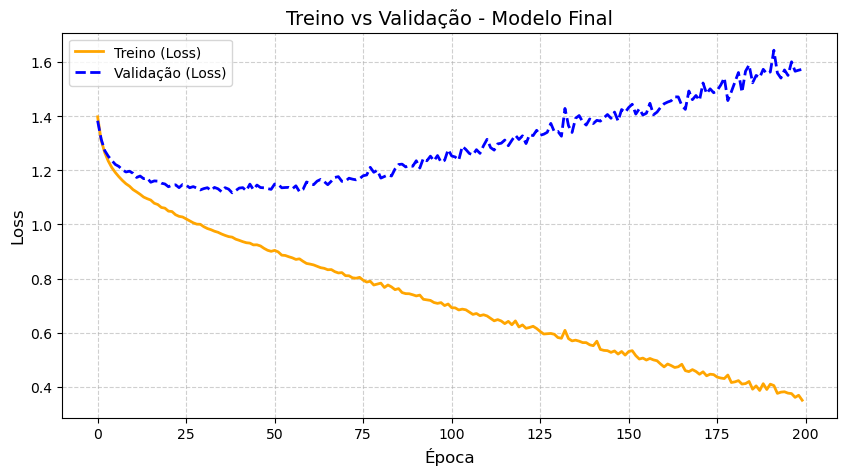


--- Avaliação Final (Conjunto de Teste) ---
Teste Accuracy: 52.24%


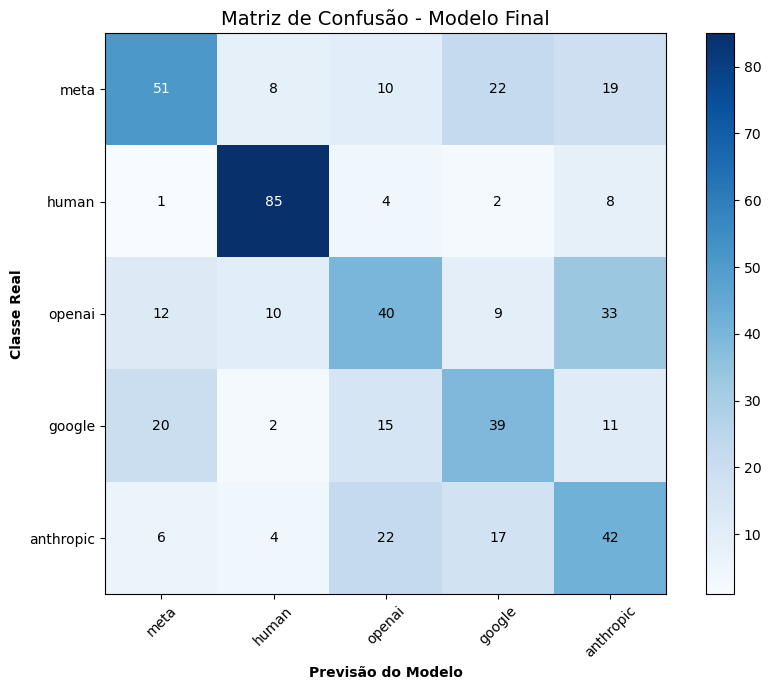

In [3]:
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../src'))
from neuralnet import NeuralNetwork
from layers import DenseLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy

# 1. Recriar a rede com a arquitetura simplificada (vencedora)
numpy_model = NeuralNetwork(loss_func=CategoricalCrossEntropy())
lr, mom = 0.005, 0.9 

# Apenas UMA camada oculta
numpy_model.add(DenseLayer(X_train.shape[1], 64, lr, mom))
numpy_model.add(ReLUActivation())
numpy_model.add(DenseLayer(64, len(labels_list), lr, mom))
numpy_model.add(SoftmaxActivation())

print("\n--- Iniciando Treino Final com Monitorização ---")
epochs = 200
batch_size = 32

history_train_loss = []
history_val_loss = []

# 2. Treinar 1 época de cada vez para podermos capturar e plotar a Validação
for epoch in range(epochs):
    # Treina apenas 1 época (verbose=False para o print ficar mais limpo)
    numpy_model.fit(X_train, Y_train, epochs=1, batch_size=batch_size, verbose=False)
    
    # Captura as perdas
    train_loss = numpy_model.history['loss'][-1]
    history_train_loss.append(train_loss)
    
    val_loss, val_accuracy = numpy_model.evaluate(X_val, Y_val)
    history_val_loss.append(val_loss)
    
    # Faz print a cada 10 épocas e na última
    if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# 3. Plot das Duas Curvas (Treino vs Validação)
plt.figure(figsize=(10, 5))
plt.plot(history_train_loss, label='Treino (Loss)', color='orange', linewidth=2)
plt.plot(history_val_loss, label='Validação (Loss)', color='blue', linewidth=2, linestyle='--')
plt.title('Treino vs Validação - Modelo Final', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 4. Avaliação no Conjunto de Teste (A verdadeira prova dos 9)
y_pred_proba = numpy_model.forward_propagation(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(Y_test, axis=1)

accuracy = np.mean(y_pred == y_true) * 100
print(f"\n--- Avaliação Final (Conjunto de Teste) ---")
print(f"Teste Accuracy: {accuracy:.2f}%")

# 5. Matriz de Confusão
cm = np.zeros((len(labels_list), len(labels_list)), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Matriz de Confusão - Modelo Final', fontsize=14)
plt.colorbar()

tick_marks = np.arange(len(labels_list))
plt.xticks(tick_marks, labels_list, rotation=45)
plt.yticks(tick_marks, labels_list)

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")

plt.xlabel('Previsão do Modelo', fontweight='bold')
plt.ylabel('Classe Real', fontweight='bold')
plt.tight_layout()
plt.show()

# Pytorch

A usar dispositivo: cuda

--- Treino PyTorch Iniciado ---
Epoch 10/80 | Train Loss: 0.8754 | Val Loss: 1.0881
Epoch 20/80 | Train Loss: 0.6946 | Val Loss: 1.2741
Epoch 30/80 | Train Loss: 0.5162 | Val Loss: 1.4679
Epoch 40/80 | Train Loss: 0.3484 | Val Loss: 1.9703
Epoch 50/80 | Train Loss: 0.2301 | Val Loss: 2.0783
Epoch 60/80 | Train Loss: 0.1967 | Val Loss: 1.9408
Epoch 70/80 | Train Loss: 0.1548 | Val Loss: 1.9922
Epoch 80/80 | Train Loss: 0.2002 | Val Loss: 1.7783


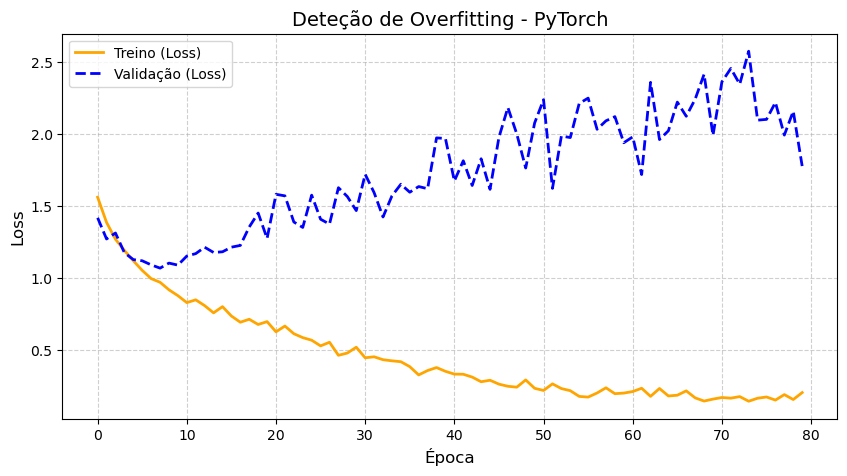


PyTorch Accuracy (Conjunto de Teste): 57.72%


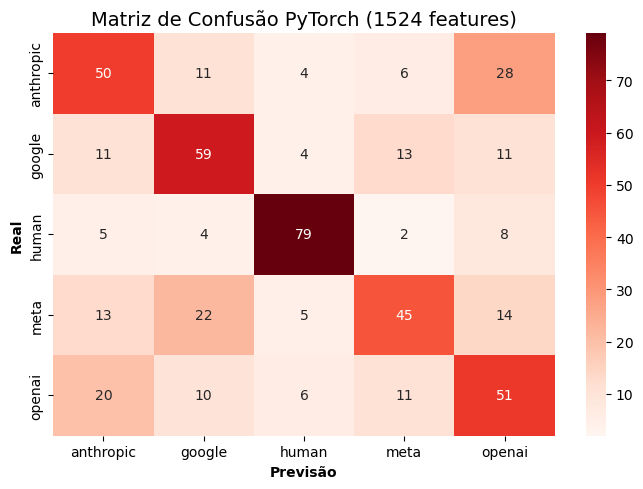

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"A usar dispositivo: {device}")

# 1. Preparação Sklearn (Atualizado para StandardScaler)
scaler = StandardScaler()
X_extra_scaled = scaler.fit_transform(X_extra)
X_combined_pt = np.hstack((X_tfidf, X_extra_scaled))

encoder = LabelEncoder()
y_pt = encoder.fit_transform(df['label'])

# --- DIVISÃO COM VALIDAÇÃO (70% Treino, 10% Validação, 20% Teste) ---
X_temp, X_test, y_temp, y_test = train_test_split(X_combined_pt, y_pt, test_size=0.2, stratify=y_pt, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42)

# 2. Tensores e Loaders
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train).to(device), torch.LongTensor(y_train).to(device)), 
    batch_size=32, 
    shuffle=True
)

X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)

X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

# 3. Modelo PyTorch (Afinado para 1524 features e dados esparsos)
class DetectorIADeep(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 1012), 
            nn.ReLU(), 
            nn.Dropout(0.5), # Aumentamos o Dropout para 50%
            nn.Linear(1012, 512), 
            nn.ReLU(), 
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(), 
            nn.Dropout(0.5),
            nn.Linear(128, 32), 
            nn.ReLU(), 
            nn.Dropout(0.5), # Aumentamos o Dropout para 50%
            nn.Linear(32, num_classes)
        )
    def forward(self, x): 
        return self.net(x)

model = DetectorIADeep(X_train.shape[1], len(encoder.classes_)).to(device)
# Otimizador com penalização mais leve para permitir aprendizagem profunda
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# 4. Treino com Captura de Validação
print("\n--- Treino PyTorch Iniciado ---")
epochs = 80 # Reduzido para evitar overfitting severo
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    epoch_train_loss = np.mean(batch_losses)
    train_losses.append(epoch_train_loss)
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_losses.append(val_loss.item())
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {val_loss.item():.4f}")

# 5. Plot das Curvas de Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Treino (Loss)', color='orange', linewidth=2)
plt.plot(val_losses, label='Validação (Loss)', color='blue', linewidth=2, linestyle='--')
plt.title('Deteção de Overfitting - PyTorch', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 6. Accuracy e Matriz Seaborn no Conjunto de Teste
model.eval() 
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)
    acc = 100 * (predicted == y_test_t).sum().item() / y_test_t.size(0)

print(f"\nPyTorch Accuracy (Conjunto de Teste): {acc:.2f}%")

cm_pt = confusion_matrix(y_test_t.cpu(), predicted.cpu())
plt.figure(figsize=(7, 5))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Reds', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f'Matriz de Confusão PyTorch ({X_train.shape[1]} features)', fontsize=14)
plt.xlabel('Previsão', fontweight='bold')
plt.ylabel('Real', fontweight='bold')
plt.tight_layout()
plt.show()

# Teste

Novo dataset carregado com 125 amostras.
Labels corrigidas para coincidir com o treino: ['human' 'meta' 'google' 'openai' 'anthropic']
A extrair features do novo dataset...

--- A avaliar Modelo NumPy ---
NumPy Accuracy (Novo Dataset): 42.40%

--- A avaliar Modelo PyTorch ---
PyTorch Accuracy (Novo Dataset): 47.20%


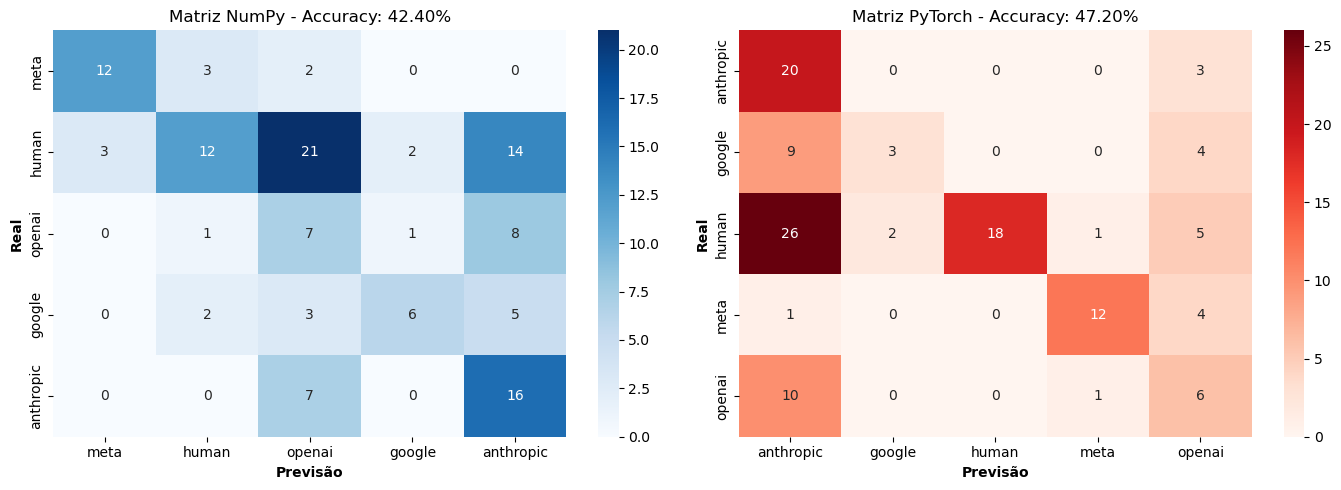

In [15]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar o Novo Dataset
caminho_novo_dataset = "../data/raw/dataset-exemplos.csv" 
df_new = pd.read_csv(caminho_novo_dataset, sep=";").dropna()

print(f"Novo dataset carregado com {len(df_new)} amostras.")

# --- CORREÇÃO DAS LABELS ---
classes_originais = list(label_to_idx.keys())
mapa_classes = {str(c).lower(): c for c in classes_originais}
df_new['Label'] = df_new['Label'].apply(lambda x: mapa_classes.get(str(x).lower(), x))

print(f"Labels corrigidas para coincidir com o treino: {df_new['Label'].unique()}")

# 2. Extração de Features
print("A extrair features do novo dataset...")
corpus_new = [str(t) for t in df_new["Text"]]

# Usamos o teu 'extractor' que já foi fittado no treino
X_tfidf_new = extractor.transform_tfidf(corpus_new)
X_extra_new = np.array([extractor._get_metrics(t) for t in corpus_new])

# ==========================================
# NORMALIZAÇÃO ÚNICA PARA AMBOS OS MODELOS
# ==========================================
# Usamos o mesmo 'scaler' que foi treinado no bloco anterior
X_extra_scaled_new = scaler.transform(X_extra_new)

# Juntar o TF-IDF com as métricas comportamentais (agora com 1524 features no total)
X_combined_new = np.hstack((X_tfidf_new, X_extra_scaled_new))

# Converter labels novas para índices
y_true_new = np.array([label_to_idx[l] for l in df_new['Label']])

# ==========================================
# TESTE 1: MODELO NUMPY 
# ==========================================
print("\n--- A avaliar Modelo NumPy ---")

# Fazer previsões (usando as novas features combinadas)
# Nota: certifica-te que a tua variável do modelo NumPy se chama 'numpy_model' ou altera aqui
y_pred_proba_np = numpy_model.forward_propagation(X_combined_new)
y_pred_np_new = np.argmax(y_pred_proba_np, axis=1)

acc_np = np.mean(y_pred_np_new == y_true_new) * 100
print(f"NumPy Accuracy (Novo Dataset): {acc_np:.2f}%")

# ==========================================
# TESTE 2: MODELO PYTORCH
# ==========================================
print("\n--- A avaliar Modelo PyTorch ---")

# Converter features para Tensores
X_new_t = torch.FloatTensor(X_combined_new).to(device)

# Converter labels com o Encoder do treino
y_pt_new = encoder.transform(df_new['Label'])
y_new_t = torch.LongTensor(y_pt_new).to(device)

# Fazer previsões
model.eval() # Garantir que o modelo está em modo avaliação (sem Dropout)
with torch.no_grad():
    outputs_new = model(X_new_t)
    _, predicted_pt_new = torch.max(outputs_new, 1)
    
acc_pt = 100 * (predicted_pt_new == y_new_t).sum().item() / y_new_t.size(0)
print(f"PyTorch Accuracy (Novo Dataset): {acc_pt:.2f}%")

# ==========================================
# PLOT DAS DUAS MATRIZES DE CONFUSÃO
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz NumPy
cm_np = confusion_matrix(y_true_new, y_pred_np_new)
sns.heatmap(cm_np, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_list, yticklabels=labels_list, ax=axes[0])
axes[0].set_title(f'Matriz NumPy - Accuracy: {acc_np:.2f}%', fontsize=12)
axes[0].set_xlabel('Previsão', fontweight='bold')
axes[0].set_ylabel('Real', fontweight='bold')

# Matriz PyTorch
cm_pt = confusion_matrix(y_pt_new, predicted_pt_new.cpu())
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Reds', 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_, ax=axes[1])
axes[1].set_title(f'Matriz PyTorch - Accuracy: {acc_pt:.2f}%', fontsize=12)
axes[1].set_xlabel('Previsão', fontweight='bold')
axes[1].set_ylabel('Real', fontweight='bold')

plt.tight_layout()
plt.show()